In [2]:
import pandas as pd
import numpy as np
import re

In [3]:
data = open('WhatsApp Chat with 22-26.txt','r',encoding='utf-8')
data = data.read()

In [4]:
pattern = r'\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}\s\w{2}\s-\s'

In [5]:
date = re.findall(pattern, data)

In [6]:
messages = re.split(pattern, data)[1:]

In [7]:
messages

['Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*.\n',
 'Khabab Leghari created group "22-26"\n',
 'Khabab Leghari added you\n',
 'Umar Farooq Cls: <Media omitted>\n',
 'Umar Farooq Cls: ایک شعر لکھا ھے جو کہیں کسی کو کھونے پہ لکھا جاتا ھے \nہم سے امیدیں واپس آنے کی نہ وابستہ کر اے میرے ہمسفر \nمیں ان راستوں کا مسافر بن چکا ہوں جس کی منزل اور واپسی کی راہ نہیں\n',
 'Awais Cls: <Media omitted>\n',
 'Umar Farooq Cls: Mam class main a gye hain ,\n',
 'Umar Farooq Cls: <Media omitted>\n',
 'Umar Farooq Cls: SNA and IT PM ka kal assignment sub met kerna lazmi\n',
 'Shshbaz IT: Assignment pages pr lekh kr ana hb ya simple pages\n',
 'Umar Farooq Cls: <Media omitted>\n',
 'Umar Farooq Cls: Anyone interested? If yes ,sent me your name,Thank you\n',
 'Awais Cls: Assignment pages py\n',
 'Umar Farooq Cls: https://youtu.be/lKzfUf7KbMs?si=ZdKWZZmVOJRVh0Tz\n',
 'Umar Farooq Cls: Mr ubair sent it\n',
 'Umar Farooq Cls: اے میرے دل

In [8]:
data = pd.DataFrame({'message_date':date, 'user_message':messages})
data.head()

,message_date,user_message
0,"9/24/24, 11:28 AM -",Messages and calls are end-to-end encrypted. O...
1,"5/7/24, 7:39 AM -","Khabab Leghari created group ""22-26""\n"
2,"9/24/24, 11:28 AM -",Khabab Leghari added you\n
3,"9/25/24, 7:09 PM -",Umar Farooq Cls: <Media omitted>\n
4,"9/25/24, 8:10 PM -",Umar Farooq Cls: ایک شعر لکھا ھے جو کہیں کسی ک...


In [9]:
data['message_date'] = data['message_date'].str.replace('\u202f',' ')

In [10]:
data.head()

,message_date,user_message
0,"9/24/24, 11:28 AM -",Messages and calls are end-to-end encrypted. O...
1,"5/7/24, 7:39 AM -","Khabab Leghari created group ""22-26""\n"
2,"9/24/24, 11:28 AM -",Khabab Leghari added you\n
3,"9/25/24, 7:09 PM -",Umar Farooq Cls: <Media omitted>\n
4,"9/25/24, 8:10 PM -",Umar Farooq Cls: ایک شعر لکھا ھے جو کہیں کسی ک...


In [11]:
data['message_date'] = pd.to_datetime(data['message_date'],format = '%m/%d/%y, %I:%M %p - ')

In [12]:
users = []
messge = []
expression = r'([\w\W+?]:\s)'

for message in data['user_message']:
    entry = re.split(expression, message)
    if entry[1:]:
        users.append(entry[1])
        messge.append(" ".join(entry[2:]))
    else:
        users.append('Group Notification')
        messge.append(entry[0])


In [13]:
users = []
messages = []

for message in data['user_message']:
    # Check if the message has a colon
    if ": " in message:
        possible_user, msg = message.split(": ", 1)
        # Use regex to check if this is a valid username (letters, spaces, maybe dots)
        if re.match(r'^[\w\s\.]+$', possible_user):
            users.append(possible_user)
            messages.append(msg)
        else:
            users.append("Group Notification")
            messages.append(message)
    else:
        users.append("Group Notification")
        messages.append(message)

In [14]:
print(messages)

['Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*.\n', 'Khabab Leghari created group "22-26"\n', 'Khabab Leghari added you\n', '<Media omitted>\n', 'ایک شعر لکھا ھے جو کہیں کسی کو کھونے پہ لکھا جاتا ھے \nہم سے امیدیں واپس آنے کی نہ وابستہ کر اے میرے ہمسفر \nمیں ان راستوں کا مسافر بن چکا ہوں جس کی منزل اور واپسی کی راہ نہیں\n', '<Media omitted>\n', 'Mam class main a gye hain ,\n', '<Media omitted>\n', 'SNA and IT PM ka kal assignment sub met kerna lazmi\n', 'Assignment pages pr lekh kr ana hb ya simple pages\n', '<Media omitted>\n', 'Anyone interested? If yes ,sent me your name,Thank you\n', 'Assignment pages py\n', 'https://youtu.be/lKzfUf7KbMs?si=ZdKWZZmVOJRVh0Tz\n', 'Mr ubair sent it\n', 'اے میرے دل! مجھ سے اب زیادہ امید نہ رکھ جینے کی \nکیا خبر اب ہم کس لمحے سانسیں گننے لگیں\n', 'C3 lecture start\n', 'Assignment 05 PM tak aj submit ker saktay hain ,Web ka five times print name wala\n', 'Kal ko quiz kon kon say su

In [15]:
data['users']= users

In [16]:
data['messages'] = messages

In [17]:
data.head()

,message_date,user_message,users,messages
0,2024-09-24 11:28:00,Messages and calls are end-to-end encrypted. O...,Group Notification,Messages and calls are end-to-end encrypted. O...
1,2024-05-07 07:39:00,"Khabab Leghari created group ""22-26""\n",Group Notification,"Khabab Leghari created group ""22-26""\n"
2,2024-09-24 11:28:00,Khabab Leghari added you\n,Group Notification,Khabab Leghari added you\n
3,2024-09-25 19:09:00,Umar Farooq Cls: <Media omitted>\n,Umar Farooq Cls,<Media omitted>\n
4,2024-09-25 20:10:00,Umar Farooq Cls: ایک شعر لکھا ھے جو کہیں کسی ک...,Umar Farooq Cls,ایک شعر لکھا ھے جو کہیں کسی کو کھونے پہ لکھا ج...


In [18]:
data['only_date'] = data['message_date'].dt.date
data['year'] = data['message_date'].dt.year
data['month_num'] = data['message_date'].dt.month
data['month'] = data['message_date'].dt.month_name()
data['day'] = data['message_date'].dt.day
data['day_name'] = data['message_date'].dt.day_name()
data['hour'] = data['message_date'].dt.hour
data['minute'] = data['message_date'].dt.minute

In [19]:
data.drop(columns = ['user_message','message_date'],inplace=True)

In [20]:
data.head()

,users,messages,only_date,year,month_num,month,day,day_name,hour,minute
0,Group Notification,Messages and calls are end-to-end encrypted. O...,2024-09-24,2024,9,September,24,Tuesday,11,28
1,Group Notification,"Khabab Leghari created group ""22-26""\n",2024-05-07,2024,5,May,7,Tuesday,7,39
2,Group Notification,Khabab Leghari added you\n,2024-09-24,2024,9,September,24,Tuesday,11,28
3,Umar Farooq Cls,<Media omitted>\n,2024-09-25,2024,9,September,25,Wednesday,19,9
4,Umar Farooq Cls,ایک شعر لکھا ھے جو کہیں کسی کو کھونے پہ لکھا ج...,2024-09-25,2024,9,September,25,Wednesday,20,10


In [21]:
period = []
for hour in data[['day_name', 'hour']]['hour']:
    if hour == 23:
        period.append(str(hour) + "-" + str('00'))
    elif hour == 0:
        period.append(str('00') + "-" + str(hour + 1))
    else:
        period.append(str(hour) + "-" + str(hour + 1))
        
data['period'] = period

In [22]:
data.head()

,users,messages,only_date,year,month_num,month,day,day_name,hour,minute,period
0,Group Notification,Messages and calls are end-to-end encrypted. O...,2024-09-24,2024,9,September,24,Tuesday,11,28,11-12
1,Group Notification,"Khabab Leghari created group ""22-26""\n",2024-05-07,2024,5,May,7,Tuesday,7,39,7-8
2,Group Notification,Khabab Leghari added you\n,2024-09-24,2024,9,September,24,Tuesday,11,28,11-12
3,Umar Farooq Cls,<Media omitted>\n,2024-09-25,2024,9,September,25,Wednesday,19,9,19-20
4,Umar Farooq Cls,ایک شعر لکھا ھے جو کہیں کسی کو کھونے پہ لکھا ج...,2024-09-25,2024,9,September,25,Wednesday,20,10,20-21


In [23]:
data.shape

(4848, 11)

In [24]:
x = data['users'].value_counts().head()

In [25]:
name = x.index
value = x.values

In [26]:
import matplotlib.pyplot as plt

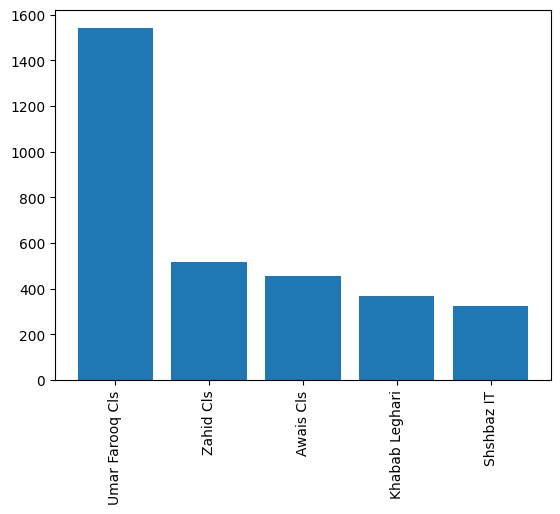

In [27]:
plt.bar(name, value)
plt.xticks(rotation = 'vertical')
plt.show()

In [28]:
round((data['users'].value_counts()/(data.shape[0]))*100,2).reset_index().rename({'users':'name','count':'percent'})

,users,count
0,Umar Farooq Cls,31.81
1,Zahid Cls,10.68
2,Awais Cls,9.43
3,Khabab Leghari,7.59
4,Shshbaz IT,6.72
5,Group Notification,6.39
6,Shaheryar Saif,6.19
7,Haroon Cls,4.95
8,Mashood CF,3.73
9,Zain IT,3.14


In [29]:
temp = data[~data['messages'].str.contains('Media omitted', na=False)]

In [30]:
temp = temp[temp['users'] != 'Group Notification']

In [31]:
temp

,users,messages,only_date,year,month_num,month,day,day_name,hour,minute,period
4,Umar Farooq Cls,ایک شعر لکھا ھے جو کہیں کسی کو کھونے پہ لکھا ج...,2024-09-25,2024,9,September,25,Wednesday,20,10,20-21
6,Umar Farooq Cls,"Mam class main a gye hain ,\n",2024-09-30,2024,9,September,30,Monday,11,36,11-12
8,Umar Farooq Cls,SNA and IT PM ka kal assignment sub met kerna ...,2024-10-01,2024,10,October,1,Tuesday,19,45,19-20
9,Shshbaz IT,Assignment pages pr lekh kr ana hb ya simple p...,2024-10-01,2024,10,October,1,Tuesday,19,52,19-20
11,Umar Farooq Cls,"Anyone interested? If yes ,sent me your name,T...",2024-10-01,2024,10,October,1,Tuesday,20,36,20-21
...,...,...,...,...,...,...,...,...,...,...,...
4842,Zain IT,subha ana hy ab ?\n,2026-03-09,2026,3,March,9,Monday,22,17,22-23
4844,Shaheryar Saif,🤣😆🤣😆\n,2026-03-09,2026,3,March,9,Monday,22,22,22-23
4845,Shaheryar Saif,<View once voice message omitted>\n,2026-03-09,2026,3,March,9,Monday,22,25,22-23
4846,Younis Sajjad,"All Concerned\nHigher Education Department, Go...",2026-03-09,2026,3,March,9,Monday,22,26,22-23


In [32]:
s = open('stop_hinglish.txt', 'r',encoding='utf-8')
stop_words = s.read()

In [33]:
words = []
for message in temp['messages']:
    for word in message.lower().split():
        if word not in stop_words:
            words.append(word)
    
words

['شعر',
 'لکھا',
 'جو',
 'کسی',
 'کھونے',
 'لکھا',
 'جاتا',
 'ہم',
 'امیدیں',
 'واپس',
 'آنے',
 'وابستہ',
 'اے',
 'میرے',
 'ہمسفر',
 'ان',
 'راستوں',
 'مسافر',
 'بن',
 'چکا',
 'جس',
 'منزل',
 'واپسی',
 'mam',
 'class',
 'sna',
 'pm',
 'assignment',
 'kerna',
 'lazmi',
 'assignment',
 'pages',
 'lekh',
 'simple',
 'pages',
 'interested?',
 ',sent',
 'name,thank',
 'assignment',
 'pages',
 'https://youtu.be/lkzfuf7kbms?si=zdkwzzmvojrvh0tz',
 'mr',
 'ubair',
 'اے',
 'میرے',
 'دل!',
 'مجھ',
 'اب',
 'زیادہ',
 'امید',
 'جینے',
 'کیا',
 'اب',
 'ہم',
 'کس',
 'لمحے',
 'سانسیں',
 'گننے',
 'c3',
 'lecture',
 'start',
 'assignment',
 '05',
 'pm',
 'submit',
 'ker',
 'saktay',
 ',web',
 'print',
 'quiz',
 'subject',
 'hay?????',
 'class',
 'attendance',
 'start',
 'minutes,after',
 '....no',
 'attendance',
 'agher',
 'previous',
 'semester',
 'department',
 'treasure',
 'copy',
 'deni',
 'hay',
 'submit',
 'ker',
 'saktay',
 'write',
 'application',
 'submitting',
 'previous',
 'semester',
 '(',
 '

In [34]:
from collections import Counter
pd.DataFrame(Counter(words).most_common(20))

,0,1
0,class,236
1,deleted,84
2,lecture,80
3,department,77
4,mam,76
5,project,67
6,share,61
7,students,50
8,pass,49
9,university,49


In [35]:
import emoji

In [36]:
emojis = []
for message in data['messages']:
    emojis.extend([c for c in message if c in emoji.EMOJI_DATA])

emojis

['♥',
 '👈',
 '🏻',
 '♥',
 '✨',
 '🥰',
 '😊',
 '😆',
 '😆',
 '👍',
 '🏻',
 '😂',
 '😂',
 '😂',
 '😂',
 '😂',
 '🤣',
 '🤣',
 '😂',
 '🤷',
 '♂',
 '😀',
 '🤣',
 '😁',
 '😞',
 '😞',
 '😀',
 '😀',
 '😉',
 '😌',
 '☹',
 '👈',
 '🏻',
 '❕',
 '😁',
 '🤭',
 '😃',
 '😇',
 '😁',
 '😂',
 '🤔',
 '😂',
 '😂',
 '😅',
 '😂',
 '😳',
 '😂',
 '😒',
 '😂',
 '🤝',
 '🙄',
 '😅',
 '😅',
 '😂',
 '🌝',
 '🍕',
 '😅',
 '🫣',
 '🥲',
 '😁',
 '😂',
 '😱',
 '😂',
 '😂',
 '😁',
 '😂',
 '🤲',
 '🏻',
 '🫣',
 '🥰',
 '🥰',
 '♥',
 '🔙',
 '🔙',
 '🔙',
 '🔙',
 '🔙',
 '😂',
 '👍',
 '🏻',
 '♥',
 '😂',
 '🤣',
 '🤣',
 '🤣',
 '😐',
 '😅',
 '😊',
 '🫣',
 '😎',
 '❤',
 '👍',
 '🏻',
 '😂',
 '😅',
 '😎',
 '🥲',
 '😂',
 '👍',
 '🏻',
 '😁',
 '😎',
 '😂',
 '🫣',
 '😂',
 '🙏',
 '😂',
 '😂',
 '✌',
 '✌',
 '👍',
 '🏻',
 '☑',
 '🥰',
 '🙏',
 '🫶',
 '😂',
 '😂',
 '🆗',
 '😂',
 '😂',
 '😂',
 '😂',
 '😂',
 '😂',
 '🥰',
 '😜',
 '😅',
 '❤',
 '😅',
 '🫣',
 '❤',
 '🫷',
 '🏻',
 '🫣',
 '🥹',
 '👍',
 '🏻',
 '🤣',
 '😁',
 '😁',
 '🤣',
 '😂',
 '♥',
 '😂',
 '😂',
 '♥',
 '😭',
 '💔',
 '♥',
 '🤲',
 '🏻',
 '🎈',
 '🎂',
 '🎈',
 '🎈',
 '🎂',
 '🎂',
 '🎈',
 '🎈',
 '🎂',
 '🎂',
 '♥',
 '❤',
 '❤',
 '✨',
 '✨'

In [37]:
new_df = pd.DataFrame(Counter(emojis).most_common(len(Counter(emojis))))

In [38]:
data.head()

,users,messages,only_date,year,month_num,month,day,day_name,hour,minute,period
0,Group Notification,Messages and calls are end-to-end encrypted. O...,2024-09-24,2024,9,September,24,Tuesday,11,28,11-12
1,Group Notification,"Khabab Leghari created group ""22-26""\n",2024-05-07,2024,5,May,7,Tuesday,7,39,7-8
2,Group Notification,Khabab Leghari added you\n,2024-09-24,2024,9,September,24,Tuesday,11,28,11-12
3,Umar Farooq Cls,<Media omitted>\n,2024-09-25,2024,9,September,25,Wednesday,19,9,19-20
4,Umar Farooq Cls,ایک شعر لکھا ھے جو کہیں کسی کو کھونے پہ لکھا ج...,2024-09-25,2024,9,September,25,Wednesday,20,10,20-21


In [39]:
timeline = data.groupby(['year','month_num','month']).count()['messages'].reset_index()

In [40]:
timeline

,year,month_num,month,messages
0,2024,5,May,1
1,2024,9,September,6
2,2024,10,October,151
3,2024,11,November,80
4,2024,12,December,339
5,2025,1,January,370
6,2025,2,February,287
7,2025,3,March,171
8,2025,4,April,365
9,2025,5,May,465


In [41]:
time=[]
for i in range(timeline.shape[0]):
    time.append(timeline['month'][i] + '-' + str(timeline['year'][i]))

In [42]:
time

['May-2024',
 'September-2024',
 'October-2024',
 'November-2024',
 'December-2024',
 'January-2025',
 'February-2025',
 'March-2025',
 'April-2025',
 'May-2025',
 'June-2025',
 'July-2025',
 'August-2025',
 'September-2025',
 'October-2025',
 'November-2025',
 'December-2025',
 'January-2026',
 'February-2026',
 'March-2026']

In [43]:
timeline['time'] = time

In [44]:
timeline

,year,month_num,month,messages,time
0,2024,5,May,1,May-2024
1,2024,9,September,6,September-2024
2,2024,10,October,151,October-2024
3,2024,11,November,80,November-2024
4,2024,12,December,339,December-2024
5,2025,1,January,370,January-2025
6,2025,2,February,287,February-2025
7,2025,3,March,171,March-2025
8,2025,4,April,365,April-2025
9,2025,5,May,465,May-2025


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'May-2024'),
  Text(1, 0, 'September-2024'),
  Text(2, 0, 'October-2024'),
  Text(3, 0, 'November-2024'),
  Text(4, 0, 'December-2024'),
  Text(5, 0, 'January-2025'),
  Text(6, 0, 'February-2025'),
  Text(7, 0, 'March-2025'),
  Text(8, 0, 'April-2025'),
  Text(9, 0, 'May-2025'),
  Text(10, 0, 'June-2025'),
  Text(11, 0, 'July-2025'),
  Text(12, 0, 'August-2025'),
  Text(13, 0, 'September-2025'),
  Text(14, 0, 'October-2025'),
  Text(15, 0, 'November-2025'),
  Text(16, 0, 'December-2025'),
  Text(17, 0, 'January-2026'),
  Text(18, 0, 'February-2026'),
  Text(19, 0, 'March-2026')])

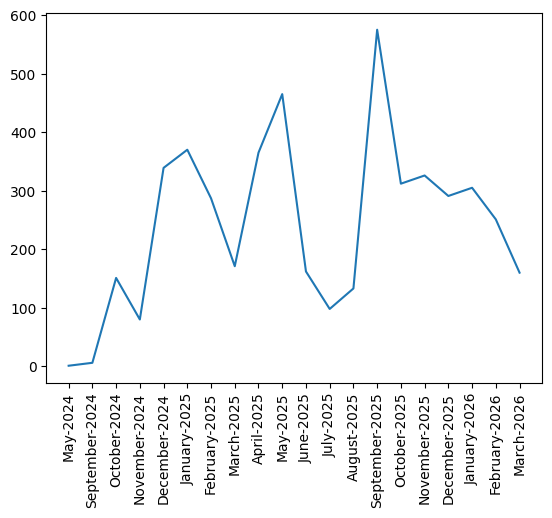

In [45]:
plt.plot(timeline['time'],timeline['messages'])
plt.xticks(rotation='vertical')

In [46]:
daily_timeline = data.groupby(['only_date']).count()['messages'].reset_index()

In [47]:
daily_timeline

,only_date,messages
0,2024-05-07,1
1,2024-09-24,2
2,2024-09-25,2
3,2024-09-26,1
4,2024-09-30,1
...,...,...
392,2026-03-04,5
393,2026-03-05,6
394,2026-03-07,21
395,2026-03-08,6


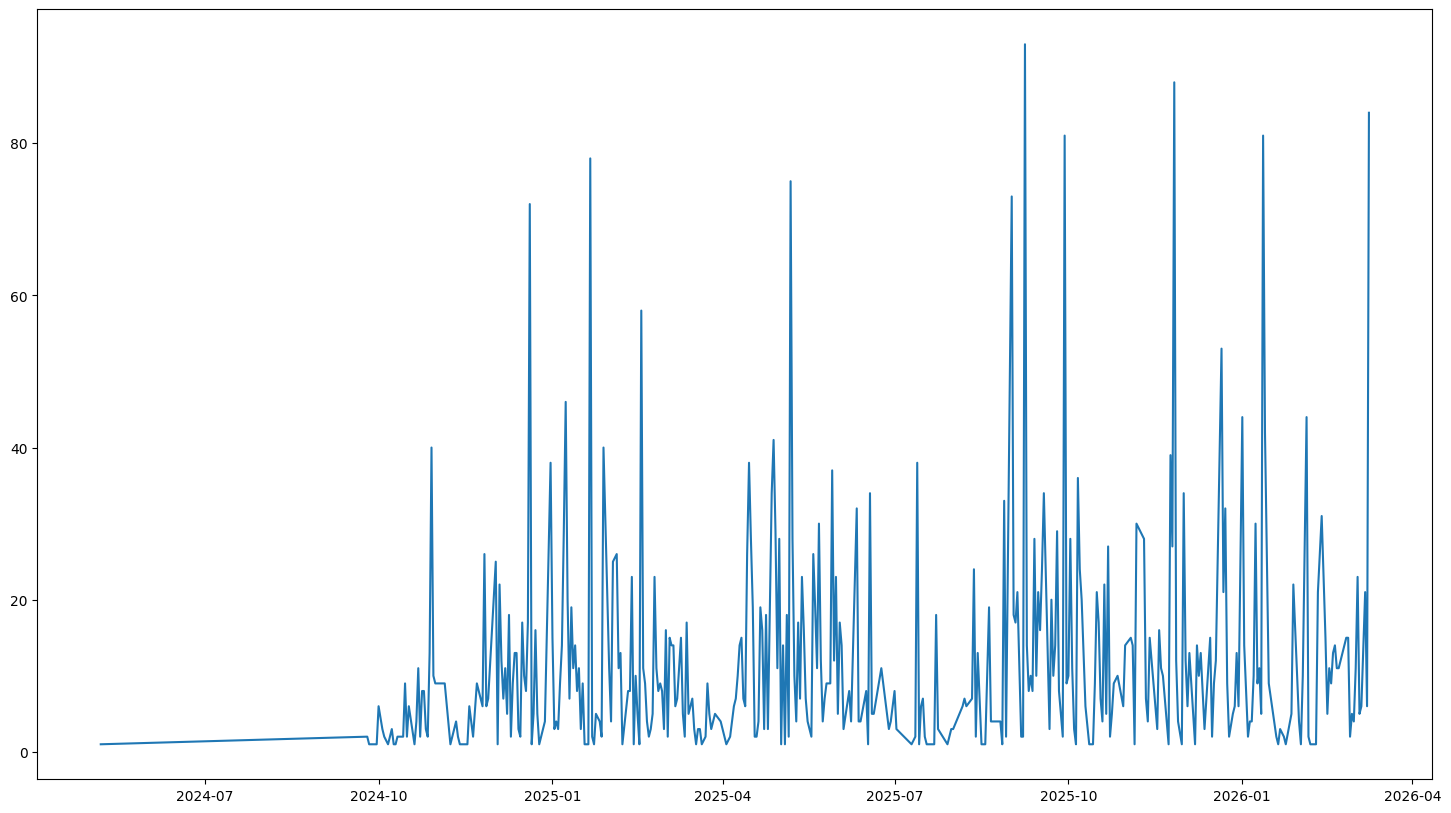

In [48]:
plt.figure(figsize=(18,10))
plt.plot(daily_timeline['only_date'],daily_timeline['messages'])
plt.show()

In [49]:
data.head()

,users,messages,only_date,year,month_num,month,day,day_name,hour,minute,period
0,Group Notification,Messages and calls are end-to-end encrypted. O...,2024-09-24,2024,9,September,24,Tuesday,11,28,11-12
1,Group Notification,"Khabab Leghari created group ""22-26""\n",2024-05-07,2024,5,May,7,Tuesday,7,39,7-8
2,Group Notification,Khabab Leghari added you\n,2024-09-24,2024,9,September,24,Tuesday,11,28,11-12
3,Umar Farooq Cls,<Media omitted>\n,2024-09-25,2024,9,September,25,Wednesday,19,9,19-20
4,Umar Farooq Cls,ایک شعر لکھا ھے جو کہیں کسی کو کھونے پہ لکھا ج...,2024-09-25,2024,9,September,25,Wednesday,20,10,20-21


In [51]:
data['day_name'].value_counts()

day_name
Monday       1195
Tuesday       957
Wednesday     885
Thursday      837
Friday        383
Sunday        331
Saturday      260
Name: count, dtype: int64

In [52]:
data['month'].value_counts()

month
January      675
December     630
September    581
February     538
May          466
October      463
November     406
April        365
March        331
June         162
August       133
July          98
Name: count, dtype: int64